In [2]:
# Лабораторная работа №7:

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Загрузка данных
df = pd.read_csv('/home/ranhart/Desktop/py/ad/lab7/База.csv', sep=';', encoding='cp1251')
print("Размерность данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размерность данных: (5519, 21)

Первые 5 строк:
                              УИД_Брони   ДатаБрони ВремяБрони ИсточникБрони  \
0  d192173f-fc14-11eb-9512-000c29ad50ac  13.08.2021    1:00:01        ручная   
1  43574a1f-fe8b-11eb-9512-000c29ad50ac  16.08.2021    4:12:46        ручная   
2  0e7b7a81-fe97-11eb-9512-000c29ad50ac  16.08.2021    5:37:12        ручная   
3  c7041428-f90b-11eb-9512-000c29ad50ac  09.08.2021    4:17:35        ручная   
4  60090518-fe8b-11eb-9512-000c29ad50ac  16.08.2021    4:13:35        ручная   

  ВременнаяБронь СледующийСтатус      Город     ВидПомещения   Тип  \
0             Да        Свободна  Ярославль  жилые помещения  2,5к   
1             Да        Свободна  Ярославль  жилые помещения  3,5к   
2             Да        Свободна  Ярославль  жилые помещения  2,5к   
3             Да        Свободна     Тюмень  жилые помещения  2,5к   
4             Да        Свободна  Ярославль  жилые помещения  2,5к   

  ПродаваемаяПлощадь  ...  СтоимостьНаДатуБрони   

In [4]:
# 2. Предварительная фильтрация
# a. Оставляем только жилые помещения
df = df[df['ВидПомещения'] == 'жилые помещения']
df = df.drop(columns=['ВидПомещения'])

# b. Удаляем строки, где статус не определен, и кодируем целевой признак
df = df[df['СледующийСтатус'].isin(['Продана', 'Свободна'])]
df['СледующийСтатус'] = df['СледующийСтатус'].map({'Продана': 1, 'Свободна': 0})

# c. Удаляем УИД_Брони
df = df.drop(columns=['УИД_Брони'])

In [5]:
# 3. Проверка типов данных и преобразование
# a. Числовые поля
numeric_cols = ['ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони', 
                'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# b. Бинарные признаки
binary_cols = ['ИсточникБрони', 'ВременнаяБронь', 'ТипСтоимости', 
               'ВариантОплаты', 'СделкаАН', 'ИнвестиционныйПродукт', 'Привилегия']
for col in binary_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# c. Категориальные небинарные признаки
categorical_cols = ['Город']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# d. Поле "Тип"
def convert_room_type(x):
    if isinstance(x, str):
        if x.endswith('к'):
            return float(x.replace('к', '').replace(',', '.'))
        elif x == 'с':
            return np.nan
    return x

df['Тип'] = df['Тип'].apply(convert_room_type)

In [6]:
# 4. Обработка отсутствующих данных
# a. СкидкаНаКвартиру -> 0
df['СкидкаНаКвартиру'] = df['СкидкаНаКвартиру'].fillna(0)

# b. Тип и ПродаваемаяПлощадь -> медиана
df['Тип'] = df['Тип'].fillna(df['Тип'].median())
df['ПродаваемаяПлощадь'] = df['ПродаваемаяПлощадь'].fillna(df['ПродаваемаяПлощадь'].median())

# c. ВариантОплатыДоп
df['ВариантОплатыДоп'] = df['ВариантОплатыДоп'].fillna(df['ВариантОплаты'])
le_dop = LabelEncoder()
df['ВариантОплатыДоп'] = le_dop.fit_transform(df['ВариантОплатыДоп'].astype(str))

# d. Удаление строк с малым количеством пропусков (менее 5%)
threshold = len(df) * 0.05
df = df.dropna(thresh=len(df.columns) - threshold)

In [7]:
# 5. Дополнение данных
# a. Цена за квадратный метр
df['ЦенаЗаКвадратныйМетр'] = df['ФактическаяСтоимостьПомещения'] / df['ПродаваемаяПлощадь']

# b. Скидка в процентах
df['СкидкаВПроцентах'] = (df['СкидкаНаКвартиру'] / df['СтоимостьНаДатуБрони']) * 100


In [8]:
# 6. Нормализация
# Минимаксная нормализация
scaler = MinMaxScaler()
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('СкидкаНаКвартиру')  # исключаем для особой обработки
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Особый случай для СкидкаНаКвартиру
df['СкидкаНаКвартиру'] = MinMaxScaler(feature_range=(-0.5, 0.5)).fit_transform(df[['СкидкаНаКвартиру']])

In [9]:
# 7. Проверка на сбалансированность
target_counts = df['СледующийСтатус'].value_counts()
print(f"\nРаспределение целевого признака:\n{target_counts}")
print(f"Соотношение классов: {target_counts[0]/target_counts[1]:.2f}")


Распределение целевого признака:
СледующийСтатус
0.0    2804
1.0    1140
Name: count, dtype: int64
Соотношение классов: 2.46


In [10]:
# 8. Формирование признаков и целевой переменной
X = df.drop(columns=['СледующийСтатус'])
y = df['СледующийСтатус']

In [11]:
# 9. Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [12]:
# 10-12. Обучение моделей KNN и Decision Tree
object_cols = X_train.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    X_train = X_train.drop(columns=object_cols)
    X_test = X_test.drop(columns=object_cols)
    print(f"Удалены все строковые столбцы: {list(object_cols)}")

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

knn.fit(X_train, y_train)
dt.fit(X_train, y_train)

y_pred_knn_train = knn.predict(X_train)
y_pred_knn_test = knn.predict(X_test)
y_pred_dt_train = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

Удалены все строковые столбцы: ['ДатаБрони', 'ВремяБрони', 'Статус лида (из CRM)']


In [13]:
# 13. Оценка моделей
def evaluate_model(y_true, y_pred, model_name, dataset):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{model_name} ({dataset}): Precision={precision:.3f}, Recall={recall:.3f}, F={f1:.3f}")
    return precision, recall, f1

print("\nОценка моделей:")
evaluate_model(y_train, y_pred_knn_train, "KNN", "train")
evaluate_model(y_test, y_pred_knn_test, "KNN", "test")
evaluate_model(y_train, y_pred_dt_train, "Decision Tree", "train")
evaluate_model(y_test, y_pred_dt_test, "Decision Tree", "test")


Оценка моделей:
KNN (train): Precision=0.855, Recall=0.690, F=0.764


KNN (test): Precision=0.770, Recall=0.621, F=0.688
Decision Tree (train): Precision=1.000, Recall=0.985, F=0.992
Decision Tree (test): Precision=0.776, Recall=0.718, F=0.746


(0.7761904761904762, 0.7180616740088106, 0.7459954233409611)

In [14]:
# 14. Выводы
print("\nВыводы по основной части:")
print("1. Датасет несбалансирован, что может влиять на качество моделей.")
print("2. Decision Tree показывает признаки переобучения (высокие метрики на train, низкие на test).")
print("3. KNN показывает более стабильные результаты, но тоже страдает от дисбаланса.")


Выводы по основной части:
1. Датасет несбалансирован, что может влиять на качество моделей.
2. Decision Tree показывает признаки переобучения (высокие метрики на train, низкие на test).
3. KNN показывает более стабильные результаты, но тоже страдает от дисбаланса.


Доступные числовые столбцы в df:
['ИсточникБрони', 'ВременнаяБронь', 'СледующийСтатус', 'Тип', 'ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони', 'ТипСтоимости', 'ВариантОплаты', 'ВариантОплатыДоп', 'СкидкаНаКвартиру', 'ФактическаяСтоимостьПомещения', 'СделкаАН', 'ИнвестиционныйПродукт', 'Привилегия', 'ЦенаЗаКвадратныйМетр', 'СкидкаВПроцентах']


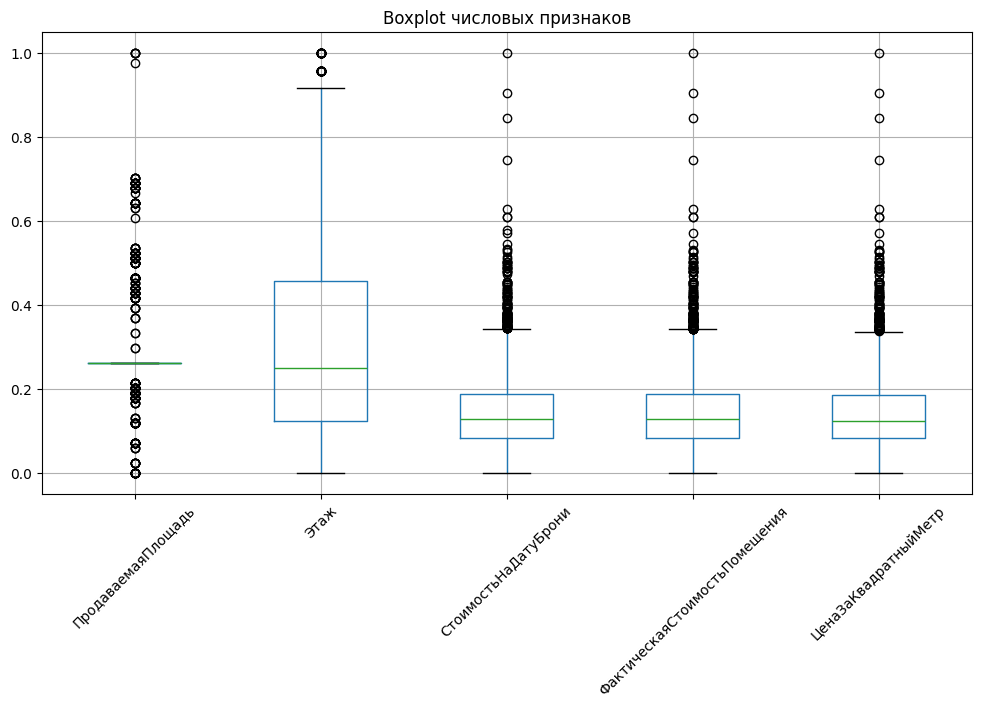

Размер после удаления выбросов: (3408, 28)
Удалены все строковые столбцы: ['ДатаБрони', 'ВремяБрони', 'Статус лида (из CRM)']

Оценка моделей после удаления выбросов:
KNN (no outliers) (test): Precision=0.804, Recall=0.575, F=0.670
Decision Tree (no outliers) (test): Precision=0.763, Recall=0.778, F=0.770


(0.7630331753554502, 0.7777777777777778, 0.7703349282296651)

In [15]:
# 15. Boxplot и удаление выбросов
print("Доступные числовые столбцы в df:")
print(df.select_dtypes(include=[np.number]).columns.tolist())
numeric_cols_for_boxplot = ['ПродаваемаяПлощадь', 'Этаж', 'СтоимостьНаДатуБрони', 
                            'ФактическаяСтоимостьПомещения', 'ЦенаЗаКвадратныйМетр']
plt.figure(figsize=(12, 6))
df[numeric_cols_for_boxplot].boxplot()
plt.title('Boxplot числовых признаков')
plt.xticks(rotation=45)
plt.show()

# Удаление выбросов по IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    return df

df_no_outliers = remove_outliers(df.copy(), numeric_cols_for_boxplot)
print(f"Размер после удаления выбросов: {df_no_outliers.shape}")

# Повторное обучение на данных без выбросов
X_no = df_no_outliers.drop(columns=['СледующийСтатус'])
y_no = df_no_outliers['СледующийСтатус']
X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(X_no, y_no, test_size=0.2, random_state=42)

knn_no = KNeighborsClassifier()
dt_no = DecisionTreeClassifier()

object_cols = X_train_no.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    X_train_no = X_train_no.drop(columns=object_cols)
    X_test_no = X_test_no.drop(columns=object_cols)
    print(f"Удалены все строковые столбцы: {list(object_cols)}")

X_train_no = X_train_no.fillna(0)
X_test_no = X_test_no.fillna(0)

knn_no.fit(X_train_no, y_train_no)
dt_no.fit(X_train_no, y_train_no)

y_pred_knn_no_test = knn_no.predict(X_test_no)
y_pred_dt_no_test = dt_no.predict(X_test_no)

print("\nОценка моделей после удаления выбросов:")
evaluate_model(y_test_no, y_pred_knn_no_test, "KNN (no outliers)", "test")
evaluate_model(y_test_no, y_pred_dt_no_test, "Decision Tree (no outliers)", "test")


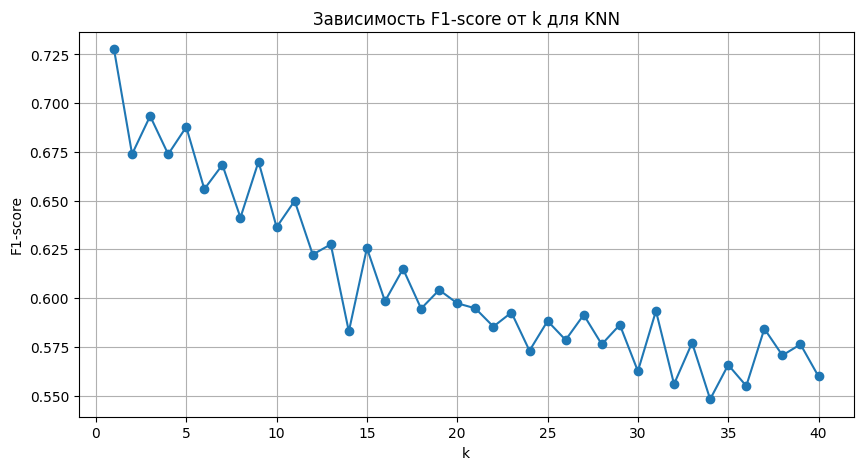

Оптимальное k для KNN: 1


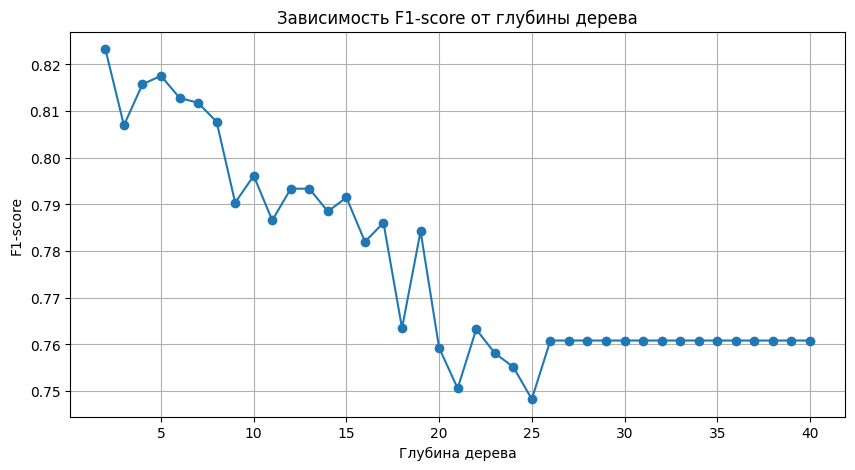

Оптимальная глубина для Decision Tree: 2


In [16]:
# 16. Подбор параметров
# KNN: подбор k
k_values = range(1, 41)
f1_scores_knn = []
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    f1_scores_knn.append(f1_score(y_test, y_pred_temp))

plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_scores_knn, marker='o')
plt.title('Зависимость F1-score от k для KNN')
plt.xlabel('k')
plt.ylabel('F1-score')
plt.grid()
plt.show()
optimal_k = k_values[np.argmax(f1_scores_knn)]
print(f"Оптимальное k для KNN: {optimal_k}")

# Decision Tree: подбор глубины
depths = range(2, 41)
f1_scores_dt = []
for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    y_pred_temp = dt_temp.predict(X_test)
    f1_scores_dt.append(f1_score(y_test, y_pred_temp))

plt.figure(figsize=(10, 5))
plt.plot(depths, f1_scores_dt, marker='o')
plt.title('Зависимость F1-score от глубины дерева')
plt.xlabel('Глубина дерева')
plt.ylabel('F1-score')
plt.grid()
plt.show()
optimal_depth = depths[np.argmax(f1_scores_dt)]
print(f"Оптимальная глубина для Decision Tree: {optimal_depth}")

In [17]:
# 17. Логистическая регрессия
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr_test = lr.predict(X_test)
print("\nЛогистическая регрессия:")
evaluate_model(y_test, y_pred_lr_test, "Logistic Regression", "test")


Логистическая регрессия:
Logistic Regression (test): Precision=0.942, Recall=0.573, F=0.712


(0.9420289855072463, 0.5726872246696035, 0.7123287671232876)

In [18]:
# 18. SVM (LinearSVC)
svm = LinearSVC(max_iter=10000)
svm.fit(X_train, y_train)
y_pred_svm_test = svm.predict(X_test)
print("\nSVM (LinearSVC):")
evaluate_model(y_test, y_pred_svm_test, "SVM", "test")



SVM (LinearSVC):
SVM (test): Precision=0.911, Recall=0.634, F=0.748


(0.9113924050632911, 0.6343612334801763, 0.7480519480519481)